# Chicago Taxi Trips - Pickup Location to Trip Miles


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_taxi import load_taxi_torch


In [2]:
DATASET_FILENAME = 'Taxi_Trips_(2013-2023)_20260317.csv'
FEATURE_SET = 'pickup'
TARGET = 'trip_miles'

# Load data
x, y = load_taxi_torch(n_sub=50_000, seed=0, feature_set=FEATURE_SET, target=TARGET, path=DATASET_FILENAME)
print(f"x shape: {x.shape}")  # (N, 2) - lon, lat
print(f"y shape: {y.shape}")  # (N,) - trip miles
print(f"Lon range: {x[:,0].min():.4f} to {x[:,0].max():.4f}")
print(f"Lat range: {x[:,1].min():.4f} to {x[:,1].max():.4f}")
print(f"Trip miles range: {y.min():.2f} to {y.max():.2f}")


x shape: torch.Size([50000, 2])
y shape: torch.Size([50000])
Lon range: -87.9136 to -87.5349
Lat range: 41.6601 to 42.0096
Trip miles range: 0.01 to 209.20


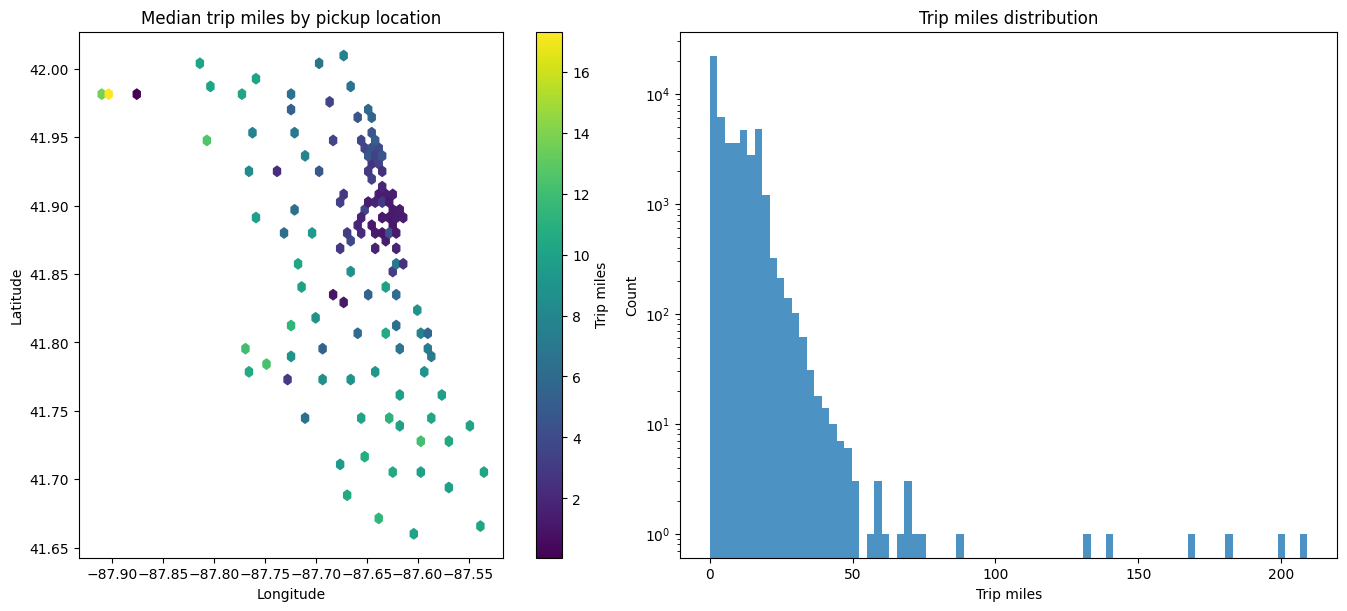

In [3]:
# Raw spatial view
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

hb = axes[0].hexbin(
    x[:,0].numpy(),
    x[:,1].numpy(),
    C=y.numpy(),
    reduce_C_function=np.median,
    gridsize=55,
    cmap='viridis',
    mincnt=5,
)
axes[0].set_title('Median trip miles by pickup location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect(1 / np.cos(np.deg2rad(float(x[:,1].mean()))))
plt.colorbar(hb, ax=axes[0], label='Trip miles')

axes[1].hist(y.numpy(), bins=80, color='tab:blue', alpha=0.8)
axes[1].set_title('Trip miles distribution')
axes[1].set_xlabel('Trip miles')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')


In [4]:
# Log-transform target for training, then standardize
y_raw = y.clone()
y = torch.log1p(y)

x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"log1p(y) mean={y.mean():.4f}, std={y.std():.4f}")


x range per dim: [0.0, 0.0] to [1.0, 1.0]
log1p(y) mean=0.0000, std=1.0000


In [7]:
EPSILON = 1e-4
kernel_type = 'SquaredExponential'
cg_tol = 1e-5


In [8]:
max_iters = 40
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol)
    optimizer.step()

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"iter {it:>3}  ell={lengthscale:.4g}  sigma_f2={variance:.4g}  sigma_n2={sigmasq:.4g}")

print(f"Final: ell={lengthscale:.4g}, sigma_f2={variance:.4g}, sigma_n2={sigmasq:.4g}")


iter   0  ell=0.1256  sigma_f2=1.105  sigma_n2=0.221
iter  10  ell=0.05207  sigma_f2=2.415  sigma_n2=0.5315
iter  20  ell=0.02891  sigma_f2=3.292  sigma_n2=0.8009
iter  30  ell=0.02195  sigma_f2=2.564  sigma_n2=0.7784
Final: ell=0.01973, sigma_f2=1.589, sigma_n2=0.6541


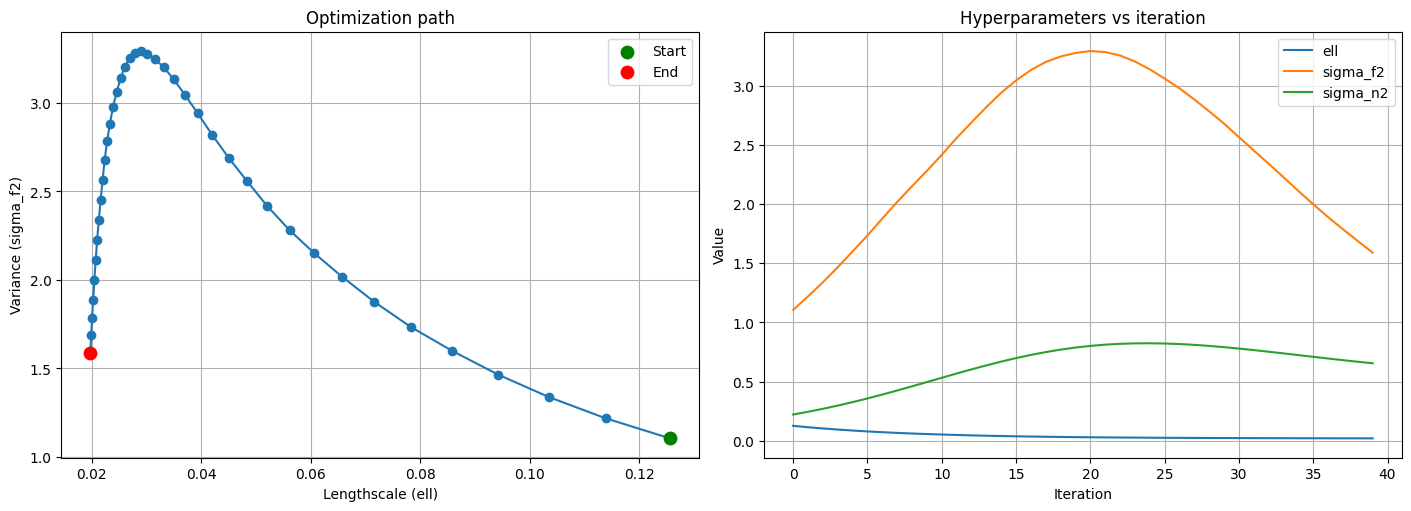

In [9]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)')
ax1.set_ylabel('Variance (sigma_f2)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ell')
ax2.plot(training_log['iter'], training_log['variance'], label='sigma_f2')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='sigma_n2')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)


In [10]:
# Predict posterior mean on a city grid
grid_res_lon = 180
grid_res_lat = 180
g_lon = torch.linspace(0, 1, grid_res_lon, dtype=x.dtype)
g_lat = torch.linspace(0, 1, grid_res_lat, dtype=x.dtype)
G_LON, G_LAT = torch.meshgrid(g_lon, g_lat, indexing='ij')
x_new = torch.stack([G_LON.flatten(), G_LAT.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

mean_log_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res_lon, grid_res_lat)
mean_grid = np.expm1(mean_log_grid)
lon_grid = (G_LON.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_grid = (G_LAT.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())


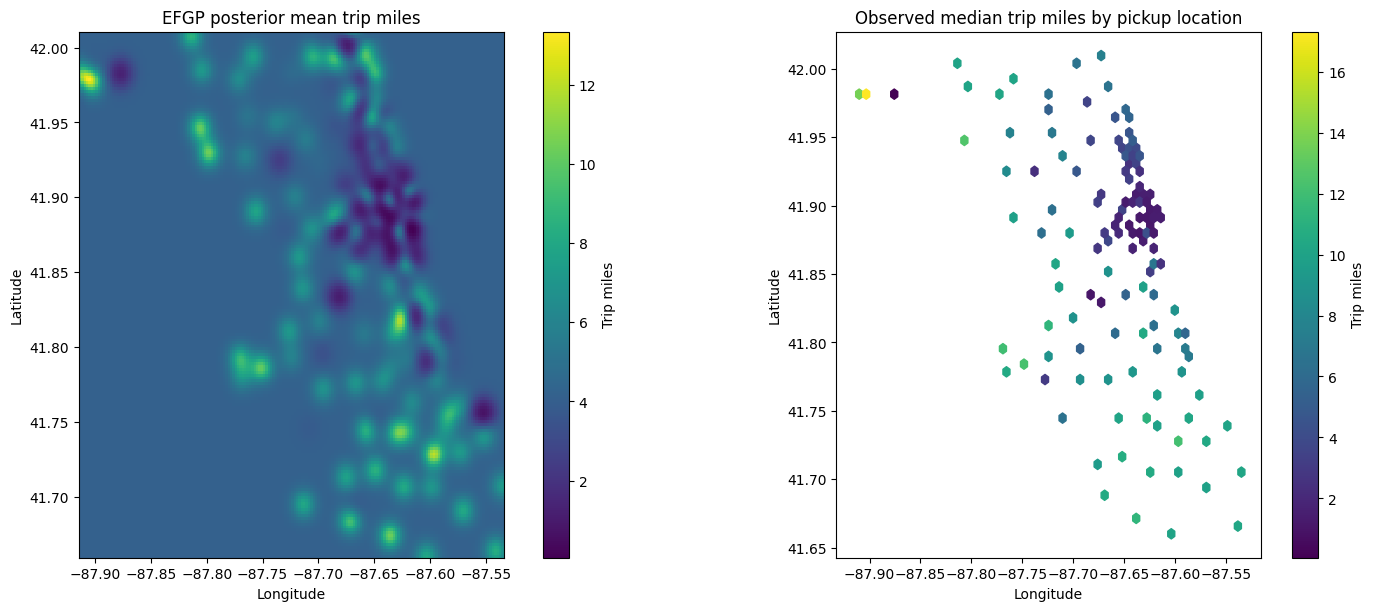

In [11]:
# Posterior surface and observed medians
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

pcm = axes[0].pcolormesh(lon_grid, lat_grid, mean_grid, cmap='viridis', shading='auto', rasterized=True)
axes[0].set_title('EFGP posterior mean trip miles')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect(1 / np.cos(np.deg2rad(float(lat_grid.mean()))))
plt.colorbar(pcm, ax=axes[0], label='Trip miles')

hb = axes[1].hexbin(
    (x[:,0] * (x_max[0] - x_min[0]) + x_min[0]).numpy(),
    (x[:,1] * (x_max[1] - x_min[1]) + x_min[1]).numpy(),
    C=y_raw.numpy(),
    reduce_C_function=np.median,
    gridsize=55,
    cmap='viridis',
    mincnt=5,
)
axes[1].set_title('Observed median trip miles by pickup location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_aspect(1 / np.cos(np.deg2rad(float(((x[:,1] * (x_max[1] - x_min[1]) + x_min[1]).mean()).item()))))
plt.colorbar(hb, ax=axes[1], label='Trip miles')
